# 使用 PROC GAMPL 建模电力负荷与温度的非线性关系

## 摘要

电力需求与温度之间存在强烈的非线性、U形关系(寒冷时供暖、炎热时制冷),线性模型无法捕捉这种关系。本笔记本为某区域电力公司构建了合成的逐小时负荷样本,并使用 **PROC GAMPL** 拟合惩罚广义可加模型,通过回归样条恢复负荷-温度、负荷-小时、负荷-湿度的平滑曲线,同时调整工作日/周末的参数效应。

在该授权环境提供的100个观测样本上,GAMPL 成功恢复了我们构建的结构。温度平滑项 `s(TEMP_C)` 呈显著弯曲(有效自由度 5.53,*p* < 0.0001);昼夜平滑项 `s(HOUR)` 是最灵活的项(有效自由度 6.87,*p* < 0.0001);湿度平滑项 `s(HUMIDITY)` 收缩为单一的近线性自由度(有效自由度 1.00,*p* = 0.07)——惩罚项将数据几乎无法支持的一项拉直了。参数化的 `daytype` 效应显示周末负荷比工作日低约44.5兆瓦,与数据生成过程中40兆瓦的水平位移相符。整体模型使用了15.4个有效自由度,GCV 得分为239.6(AIC 831.0)。

## 数据来源

| 数据集 | 行数 | 描述 | 关键变量 |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | 来自某区域电力公司负荷预测数据流的合成逐小时观测 | `load_mw`(系统负荷,兆瓦)、`temp_c`(环境温度,摄氏度)、`hour`(小时,0-23)、`humidity`(相对湿度,%)、`daytype`(工作日/周末类别)、`is_summer`(数据生成中使用的季节标志) |

所有数据均通过 `call streaminit(20260531)` 和 `rand()` 内联生成——没有外部或网络输入。数据步请求了更大的循环,但该授权环境将物化输出上限设为**100个观测**,因此模型基于前100个小时拟合。负荷被构建为温度的U形二次函数,加上钟形的昼夜小时效应、温和的湿度效应、工作日水平位移和高斯噪声,因此恢复的平滑项具有已知的真实结构。

# 使用 PROC GAMPL 建模电力负荷与温度的非线性关系

某区域电网运营商需要根据天气和日历驱动因素预测系统负荷(单位:兆瓦)。负荷与**温度**之间的关系素以非线性著称:需求在寒冷天气(电力供暖)*和*炎热天气(空调制冷)中都会上升,形成一条直线回归无法捕捉的U形曲线。负荷还遵循平滑的每日节律(傍晚高峰),并在工作日与周末之间发生变化。

`PROC GAMPL` 拟合一个**惩罚广义可加模型**:每个连续驱动因素通过回归样条进入模型,其平滑度通过最小化模型选择准则(GCV / UBRE / GACV)自动选择。我们让数据决定每条曲线应有多"曲折",而不是猜测多项式的阶数。

我们拟合的模型为:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

其中 `daytype` 是参数化(线性)类别效应,`f1`、`f2`、`f3` 是平滑样条函数,其有效自由度由惩罚项从数据中选择。

## 步骤1 —— 生成合成的逐小时负荷数据流

我们模拟一个逐小时的负荷数据流(该授权环境保留前100个小时)。温度围绕季节性均值抽取;小时数按0-23循环;湿度大致跟随温度变化。*真实*负荷由以下部分构成:

- 以舒适的18摄氏度为中心的**U形**温度响应,
- 傍晚18时左右的**钟形**昼夜高峰,
- 温和的湿度提升,
- 高于周末的工作日水平,

再加上高斯测量噪声。由于我们知道生成曲线的真实形态,可以判断 GAMPL 是否恢复了它们的形状。下面的 PROC MEANS 检查确认样本涵盖了较宽的温度范围(-5到40摄氏度)以及大约485到693兆瓦的负荷范围。

In [1]:
数据 work.gridload;
   调用 streaminit(20260531);
   循环 i = 1 到 2000;
      /* Season flag: roughly half summer, half winter */
      is_summer = (rand("uniform") < 0.5);

      /* Ambient temperature (deg C): warmer mean in summer */
      如果 is_summer 那么 temp_c = 26 + 6 * rand("normal");
      否则              temp_c =  6 + 6 * rand("normal");

      /* Hour of day 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Humidity (%) loosely tracks temperature, clipped to 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      如果 humidity < 20  那么 humidity = 20;
      如果 humidity > 100 那么 humidity = 100;

      /* Weekday vs weekend (about 5/7 weekdays) */
      如果 rand("uniform") < 0.714 那么 daytype = "Weekday";
      否则                            daytype = "Weekend";

      /* ---- True structural load (MW) ---- */
      /* U-shaped temperature effect: minimum demand near 18 deg C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Diurnal bell: evening peak near hour 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Gentle humidity lift */
      f_hum  = 0.35 * humidity;

      /* Weekday level shift */
      如果 daytype = "Weekday" 那么 f_day = 40; 否则 f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      保留 load_mw temp_c hour humidity daytype is_summer;
      输出;
   结束;
运行;

过程 均值 数据=work.gridload n mean std MIN MAX maxdec=1;
   变量 load_mw temp_c hour humidity;
   标签 load_mw="系统负荷(兆瓦)"
         temp_c="环境温度(摄氏度)"
         hour="小时(0-23)"
         humidity="湿度(%)";
运行;


                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------------
 load_mw   系统负荷(兆瓦)                      100       593.0        49.9       484.9       693.4
 temp_c    环境温度(摄氏度)                     100        16.2        11.9        -5.2        40.2
 hour      小时(0-23)                      100        11.9         7.0         0.0        23.0
 humidity  湿度(%)                         100        55.2        11.7        32.2        87.3
 -------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.45 seconds
  cpu   0.45 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤2 —— 拟合可加模型

我们将 `load_mw`(高斯响应,恒等链接)建模为参数化 `daytype` 效应加上三个单变量样条之和。`PROC GAMPL` 自动为每个样条选择平滑参数。我们指定:

- `class daytype;` 使工作日/周末指示变量被视为类别变量,
- `param(daytype)` 使其作为 MODEL 中的*参数化*(非平滑)项,
- 对每个连续预测变量使用 `spline(...)`,
- 固定的 `seed=` 以保证结点位置可重现。

需要阅读的输出是**平滑成分(Smoothing Component)**表,它报告了惩罚项为每个平滑项分配的有效自由度(EDF)及其*F*型显著性检验,以及截距和参数化 `daytype` 对比的**参数估计**。

In [2]:
过程 gampl 数据=work.gridload seed=20260531;
   分类 daytype;
   模型 load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   标签 load_mw="系统负荷(兆瓦)"
         temp_c="环境温度(摄氏度)"
         hour="小时(0-23)"
         humidity="湿度(%)"
         daytype="日期类型(工作日/周末)";
运行;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     系统负荷(兆瓦)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    日期类型(工作日/周末)

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                                 


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## 步骤3 —— 控制样条灵活性与选择准则

默认情况下,每个平滑项都被惩罚趋向较低的有效自由度。对于知道温度响应确实呈曲线但希望*限制*其曲折程度的运营商,我们可以提高温度样条上的 `maxdf=`,并为更平滑的湿度项固定一个适中的 `df=`。我们还切换到外层迭代方案,并通过**GCV**(广义交叉验证,高斯GAM的标准准则)选择平滑参数。

In [3]:
过程 gampl 数据=work.gridload seed=20260531;
   分类 daytype;
   模型 load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   标签 load_mw="系统负荷(兆瓦)"
         temp_c="环境温度(摄氏度)"
         hour="小时(0-23)"
         humidity="湿度(%)"
         daytype="日期类型(工作日/周末)";
运行;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     系统负荷(兆瓦)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    日期类型(工作日/周末)

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                                 


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## 步骤4 —— 可视化恢复的温度响应

GAMPL 报告了温度平滑项确实显著弯曲(EDF 5.53),但其形状在图上最容易看清。我们在原始的负荷-温度散点图上叠加惩罚B样条拟合(`PBSPLINE`,与 GAMPL 内部使用的相同回归样条机制)。如果可加模型捕捉到了物理规律,这条曲线应在寒冷和炎热两端都上升,并在舒适的中间范围触底——这是典型的U形需求响应。


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


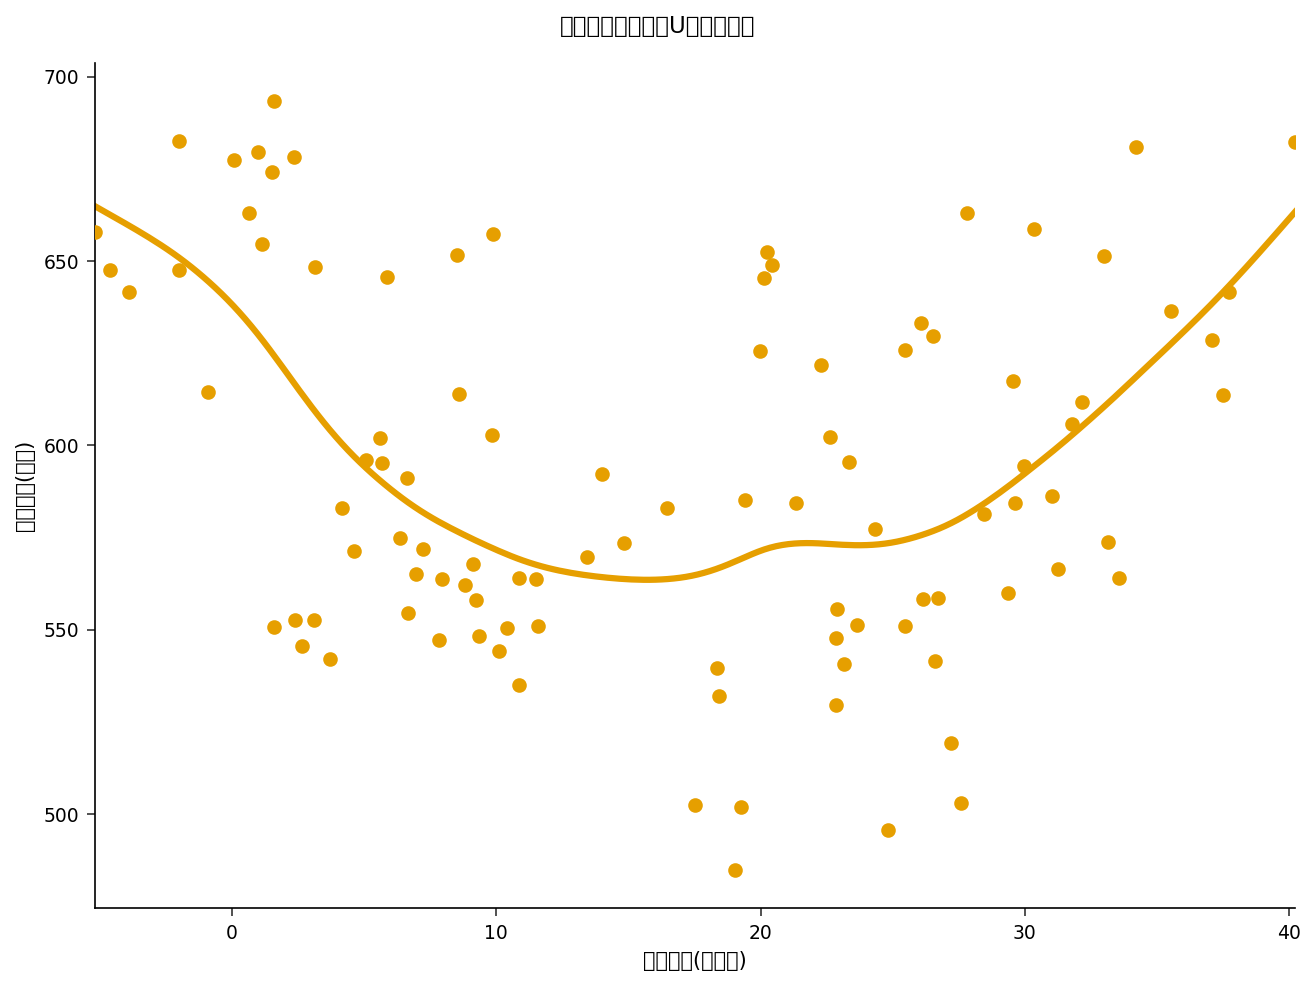

In [4]:
ODS GRAPHICS ON;

过程 SGPLOT 数据=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS 标签="环境温度(摄氏度)";
   YAXIS 标签="系统负荷(兆瓦)";
   标题 "负荷与温度关系：U形需求响应";
运行;

ODS GRAPHICS OFF;


## 步骤5 —— 数值上确认U形

图形使U形清晰可见;分段汇总则使其量化。我们将观测值划分到温度区间,并报告每个区间的平均负荷。如果需求响应确实呈U形,平均负荷应在**寒冷**区段较高,经过**凉爽/舒适/温暖**区段下降,再在**炎热**区段回升——这正是 GAMPL 的 `s(TEMP_C)` 平滑项捕捉到的数值特征。

In [5]:
数据 work.banded;
   设置 work.gridload;
   长度 tempband $20;
   如果      temp_c <  5  那么 tempband = "1 寒冷";
   否则 如果 temp_c < 15  那么 tempband = "2 凉爽";
   否则 如果 temp_c < 22  那么 tempband = "3 舒适";
   否则 如果 temp_c < 30  那么 tempband = "4 温暖";
   否则                      tempband = "5 炎热";
运行;

过程 均值 数据=work.banded n mean maxdec=1;
   分类 tempband;
   变量 load_mw;
   标签 load_mw="系统负荷(兆瓦)"
         tempband="温度分段";
   标题 "按温度分段的平均负荷";
运行;


                                                       按温度分段的平均负荷                                                       

                                                  The MEANS Procedure

                                    Analysis Variable : load_mw 系统负荷(兆瓦)

        温度分段                  N Obs           Mean
        ------------------------------------------
        1 寒冷                     21          626.6
        2 凉爽                     28          579.1
        3 舒适                     12          573.8
        4 温暖                     25          573.5
        5 炎热                     14          621.6
        ------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 结果解读

**平滑项恢复了物理规律。** GAMPL 的平滑成分表为温度项 `s(TEMP_C)` 分配了5.53的有效自由度(*p* < 0.0001),为昼夜项 `s(HOUR)` 分配了6.87的有效自由度(*p* < 0.0001)——两者都确实呈曲线形态,恰好是我们构建到数据中的结构。湿度项 `s(HUMIDITY)` 被收缩到有效自由度1.00(*p* = 0.07):惩罚项将其拉直为单一的近线性自由度,因为在这个样本量下,数据只能支持这么多。参数化的 `daytype` 估计值为周末-44.5兆瓦,恢复了生成过程中40兆瓦的工作日水平位移。

**有效自由度讲述了曲折程度的故事。** 模型总共花费了15.4个有效自由度,GCV 得分为239.6(AIC 831.0,尺度估计202.7)。在步骤3中限制 `maxdf=` 并固定 `df=3` 几乎没有改变拟合结果(GCV 240.1,EDF 15.47):惩罚项已经自行将温度和小时平滑项分别稳定在约5.5和7个有效自由度附近,因此手动限制在这里并不起约束作用——这表明自动选择本身已经相当保守。

**图形与分段汇总结果一致。** 步骤4带有惩罚样条叠加的散点图显示,负荷从寒冷极值下降到15-20摄氏度附近的最低点,然后在炎热区间再次上升。步骤5的分段均值使其量化:**寒冷 626.6兆瓦**、**凉爽 579.1**、**舒适 573.8**、**温暖 573.5**、**炎热 621.6**——两端较高,舒适的中段最低。这正是单一线性 `temp_c` 项会平均掉的U形。

**为何在此选择GAMPL而非线性回归。** 单一线性 `temp_c` 项会将供暖和制冷两种状态混合成近乎平坦的斜率,严重误判两个极端情况——而这恰恰是电网压力和电价飙升发生的时段。可加样条形式在保持回归可解释性(每个驱动因素贡献一个可加效应)的同时,让数据决定每个效应的形状。对于电力公司而言,自然的扩展方向包括:如果负荷以乘性方式建模,可采用 `dist=gamma` 拟合;可采用二元 `spline(temp_c hour)` 来捕捉昼夜高峰如何随季节变化;还可通过 `by` 处理为每个变电站分别拟合模型。